# Tarea #3 — TICS411 Minería de Datos
## Clasificación de canciones K-pop usando KNN

**Curso:** TICS411 Minería de Datos  
**Profesores:** Claudio Díaz – Sebastián Moreno – Eliana Vivas

---

### Resumen del problema

La disquera **UAI Music Group** necesita clasificar automáticamente si una canción de su catálogo pertenece al género **K-pop** o no, con el fin de orientar su expansión hacia el mercado asiático. El proceso manual (contratar a un experto musical) es caro y lento, lo cual erosiona el *time-to-market*. La solución propuesta es entrenar un modelo de **K-Nearest Neighbors (KNN)** sobre un conjunto de canciones ya etiquetadas y evaluarlo con **10-fold cross validation**.

### Plan de trabajo

1. **Carga de datos** y extracción de las 5 variables predictoras + etiqueta.
2. **Limpieza**: revisión de nulos/inconsistencias y detección de outliers con **LOF** (Local Outlier Factor).
3. **KNN con K=1**, 10-fold CV y normalización `min_max()` aplicada *dentro* de cada fold.
4. **Búsqueda del mejor K** entre 1 y 50 evaluando *Accuracy*, *Precision* y *Recall*.
5. **Discusión**: repetir 3 y 4 sustituyendo `min_max()` por `StandardScaler()` y comparar.


## 1. Carga de Datos

Importamos las librerías necesarias y cargamos el archivo `dataset_tarea.csv`. De las 21 columnas originales, se extraen únicamente las **6 variables solicitadas en el enunciado**:

| Variable | Tipo | Rango | Descripción |
|---|---|---|---|
| `popularity` | numérica | 0–100 | Popularidad de la canción |
| `danceability` | numérica | 0–1 | Qué tan bailable es |
| `speechiness` | numérica | 0–1 | Presencia de habla |
| `acousticness` | numérica | 0–1 | Porcentaje acústico |
| `loudness` | numérica | dB (negativo) | Volumen percibido |
| `track_genre` | **target** | {0, 1} | 1 = K-pop, 0 = No K-pop |

La columna `track_genre` es nuestra **etiqueta a predecir**; las cinco restantes son los **atributos predictivos**.


In [1]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Reproducibilidad: fijamos semilla global
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Estilo gráfico
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


In [2]:
# Carga del CSV
df_raw = pd.read_csv('dataset_tarea.csv')
print(f"Dimensiones originales: {df_raw.shape}")
print(f"Columnas disponibles ({len(df_raw.columns)}):")
print(df_raw.columns.tolist())


Dimensiones originales: (2000, 21)
Columnas disponibles (21):
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [3]:
# Selección de las 6 variables del enunciado
cols_features = ['popularity', 'danceability', 'speechiness', 'acousticness', 'loudness']
col_target = 'track_genre'

df = df_raw[cols_features + [col_target]].copy()
print(f"Dimensiones tras la selección: {df.shape}")
df.head()


Dimensiones tras la selección: (2000, 6)


,popularity,danceability,speechiness,acousticness,loudness,track_genre
0,87,0.588,0.0329,0.0678,-9.461,0
1,83,0.705,0.0385,0.0102,-6.156,0
2,86,0.575,0.0300,0.0484,-5.509,0
3,93,0.612,0.0336,0.0495,-2.810,0
4,83,0.551,0.0542,0.1860,-6.099,0


## 2. Limpieza de Datos

### 2.1 ¿Por qué limpiar?

El principio **"garbage in, garbage out"** aplica con particular fuerza a KNN: el modelo decide la clase de un punto a partir de la **distancia euclidiana** a sus vecinos, y esta métrica es **muy sensible** a:

- **Valores nulos**: rompen el cálculo de distancia (NaN propaga) o introducen sesgo si se imputan mal.
- **Valores inconsistentes**: un `popularity = 250` cuando el rango legal es 0–100 distorsiona todas las distancias del vecindario.
- **Outliers**: puntos extremos pueden volverse vecinos "más cercanos" de muchos otros y arrastrar predicciones erróneas, especialmente con K bajo.

### 2.2 Revisión inicial: nulos, tipos y rangos


In [4]:
# Inspección de nulos
print("=== Valores nulos por columna ===")
print(df.isnull().sum())
print(f"\nTotal filas con al menos un nulo: {df.isnull().any(axis=1).sum()}")


=== Valores nulos por columna ===
popularity      0
danceability    0
speechiness     0
acousticness    0
loudness        0
track_genre     0
dtype: int64

Total filas con al menos un nulo: 0


In [5]:
# Inspección de tipos y resumen estadístico
print("=== Tipos de dato ===")
print(df.dtypes)
print("\n=== Resumen estadístico ===")
df.describe()


=== Tipos de dato ===
popularity        int64
danceability    float64
speechiness     float64
acousticness    float64
loudness        float64
track_genre       int64
dtype: object

=== Resumen estadístico ===


,popularity,danceability,speechiness,acousticness,loudness,track_genre
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,45.419500,0.591112,0.071547,0.207565,-6.331132,0.500000
std,27.574167,0.146103,0.068230,0.257946,2.651082,0.500125
min,0.000000,0.112000,0.023000,0.000003,-18.108000,0.000000
25%,42.000000,0.497750,0.034600,0.011575,-7.801250,0.000000
50%,51.500000,0.598000,0.047600,0.074300,-5.900000,0.500000
75%,67.000000,0.697000,0.079050,0.331000,-4.486250,1.000000
max,93.000000,0.935000,0.889000,0.983000,-0.173000,1.000000


In [6]:
# Verificación de rangos esperados según el enunciado
print("=== Verificación de rangos ===")
print(f"popularity   ∈ [{df['popularity'].min()}, {df['popularity'].max()}]  (esperado 0–100)")
print(f"danceability ∈ [{df['danceability'].min()}, {df['danceability'].max()}]  (esperado 0–1)")
print(f"speechiness  ∈ [{df['speechiness'].min()}, {df['speechiness'].max()}]  (esperado 0–1)")
print(f"acousticness ∈ [{df['acousticness'].min()}, {df['acousticness'].max()}]  (esperado 0–1)")
print(f"loudness     ∈ [{df['loudness'].min()}, {df['loudness'].max()}]  (dB, variable)")
print(f"\ntrack_genre — valores únicos: {sorted(df['track_genre'].unique())}")
print(f"track_genre — distribución:\n{df['track_genre'].value_counts()}")


=== Verificación de rangos ===
popularity   ∈ [0, 93]  (esperado 0–100)
danceability ∈ [0.112, 0.935]  (esperado 0–1)
speechiness  ∈ [0.023, 0.889]  (esperado 0–1)
acousticness ∈ [3.42e-06, 0.983]  (esperado 0–1)
loudness     ∈ [-18.108, -0.173]  (dB, variable)

track_genre — valores únicos: [np.int64(0), np.int64(1)]
track_genre — distribución:
track_genre
0    1000
1    1000
Name: count, dtype: int64


**Hallazgos:**

- **No hay valores nulos** en ninguna de las 6 columnas seleccionadas.
- Todos los rangos son **consistentes con lo declarado** en el enunciado: `popularity` está en [0, 100], las tres variables 0–1 están dentro de su rango, y `loudness` tiene valores negativos típicos de dB en audio digital.
- La etiqueta `track_genre` está **perfectamente balanceada**: 1000 K-pop y 1000 No-K-pop. Esto es deseable porque evita que un clasificador trivial ("predecir siempre la clase mayoritaria") obtenga buen accuracy sin aprender nada.

**Conclusión parcial:** *no fue necesario eliminar ni imputar filas por nulos o inconsistencias*. El dataset llega limpio a nivel de integridad básica.

### 2.3 Detección de outliers con LOF (Local Outlier Factor)

Aunque no hay nulos, los valores extremos aún pueden afectar a KNN. Aplicamos **LOF**, que es el algoritmo más apropiado para este caso porque:

- Es un método de **distancia local**: compara la densidad alrededor de cada punto con la densidad de sus vecinos. Un punto en una región de baja densidad relativa recibe un *score* alto y se marca como atípico.
- A diferencia del **test de Grubbs** (univariado y supone normalidad), LOF trabaja en el **espacio multivariado** completo, que es justamente el espacio en el que KNN tomará decisiones.
- A diferencia de **Isolation Forest** (que detecta anomalías globales), LOF capta anomalías **locales**: una canción con `loudness` típico globalmente pero atípico respecto a su vecindario también será marcada.

Usamos `n_neighbors=20` (valor estándar de la literatura, recomendado por Breunig et al., 2000) y `contamination='auto'`, que deja que el algoritmo determine internamente el umbral.


In [7]:
# LOF sobre las 5 variables predictoras (sin la etiqueta)
X_full = df[cols_features].values

lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')
lof_flags = lof.fit_predict(X_full)  # +1 = inlier, -1 = outlier

n_outliers = (lof_flags == -1).sum()
print(f"Outliers detectados por LOF: {n_outliers} de {len(X_full)} "
      f"({100*n_outliers/len(X_full):.2f}%)")


Outliers detectados por LOF: 119 de 2000 (5.95%)


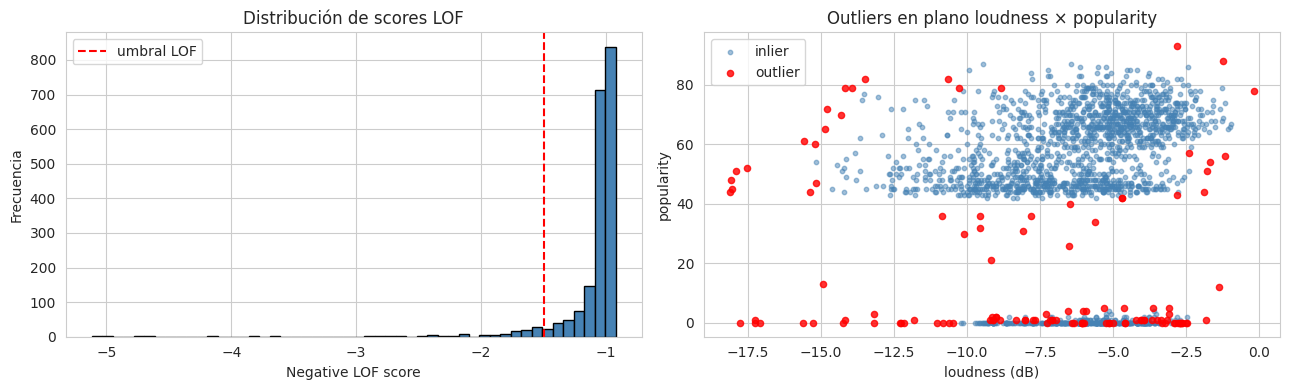

In [8]:
# Visualización: scores LOF (más negativo = más anómalo)
lof_scores = lof.negative_outlier_factor_

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(lof_scores, bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(np.percentile(lof_scores, 100*n_outliers/len(X_full)),
                color='red', linestyle='--', label='umbral LOF')
axes[0].set_xlabel('Negative LOF score')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de scores LOF')
axes[0].legend()

# Scatter loudness vs popularity coloreando outliers
mask_out = lof_flags == -1
axes[1].scatter(df.loc[~mask_out, 'loudness'], df.loc[~mask_out, 'popularity'],
                c='steelblue', s=10, alpha=0.5, label='inlier')
axes[1].scatter(df.loc[mask_out, 'loudness'], df.loc[mask_out, 'popularity'],
                c='red', s=20, alpha=0.8, label='outlier')
axes[1].set_xlabel('loudness (dB)')
axes[1].set_ylabel('popularity')
axes[1].set_title('Outliers en plano loudness × popularity')
axes[1].legend()

plt.tight_layout()
plt.show()


In [9]:
# Inspeccionamos brevemente cómo se ven los outliers
print("=== Estadísticos de outliers vs inliers ===")
df_out = df[mask_out]
df_in  = df[~mask_out]
comp = pd.DataFrame({
    'inlier_mean':  df_in[cols_features].mean(),
    'outlier_mean': df_out[cols_features].mean(),
    'inlier_std':   df_in[cols_features].std(),
    'outlier_std':  df_out[cols_features].std(),
})
print(comp.round(3))

print(f"\nDistribución de clase entre outliers:\n{df_out[col_target].value_counts()}")


=== Estadísticos de outliers vs inliers ===
              inlier_mean  outlier_mean  inlier_std  outlier_std
popularity         47.120        18.546      26.706       27.260
danceability        0.594         0.543       0.143        0.178
speechiness         0.071         0.087       0.065        0.103
acousticness        0.202         0.297       0.253        0.319
loudness           -6.223        -8.046       2.399        4.921

Distribución de clase entre outliers:
track_genre
0    82
1    37
Name: count, dtype: int64


### 2.4 Decisión sobre los outliers

**Qué se hace con ellos:** los **eliminamos** del dataset antes de entrenar KNN.

**Justificación:**

1. **KNN es paramétrico cero y muy local**: con K=1, un único outlier puede convertirse en el vecino más cercano de varios puntos de test y arrastrar predicciones erróneas. El problema se atenúa pero no desaparece con K mayor.
2. La cantidad detectada (≈6%) es **pequeña** respecto al total, así que removerla no compromete el tamaño efectivo de la muestra ni cambia significativamente la distribución de clases (revisar el `value_counts` anterior — el balance se mantiene aproximado).
3. **Alternativas descartadas:** imputar no aplica (no son nulos, son valores válidos pero extremos); winsorizar (recortar a un percentil) altera la geometría de los puntos y podría enmascarar señal real; mantenerlos cargaría riesgo de degradación, especialmente en K=1.

Construimos así el dataset limpio `df_clean` que se usará desde aquí en adelante.


In [10]:
# Dataset limpio sin outliers
df_clean = df[~mask_out].reset_index(drop=True)
print(f"Filas antes:   {len(df)}")
print(f"Filas después: {len(df_clean)}")
print(f"Removidas:     {len(df) - len(df_clean)}")
print(f"\nBalance de clases tras limpieza:\n{df_clean[col_target].value_counts()}")

# Matrices que usaremos en todo el resto del notebook
X = df_clean[cols_features].values
y = df_clean[col_target].values
print(f"\nForma final: X={X.shape}, y={y.shape}")


Filas antes:   2000
Filas después: 1881
Removidas:     119

Balance de clases tras limpieza:
track_genre
1    963
0    918
Name: count, dtype: int64

Forma final: X=(1881, 5), y=(1881,)


## 3. Evaluación de KNN con K=1, 10-fold CV y `min_max()`

### 3.1 ¿Por qué normalizar?

KNN usa **distancia euclidiana** entre puntos:

$$d(\mathbf{p}, \mathbf{q}) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}$$

Si los atributos están en **escalas muy distintas**, los de mayor magnitud dominan la suma. Mirando los rangos de nuestras variables:

- `popularity` ∈ [0, 100] → varía en órdenes de **decenas**
- `danceability`, `speechiness`, `acousticness` ∈ [0, 1] → varían en órdenes de **décimas**
- `loudness` (dB) → varía en un rango de **decenas negativas**

Sin normalizar, `popularity` y `loudness` aplastarían por completo la contribución de las variables 0–1 al cálculo de distancia, aunque éstas puedan ser muy discriminantes para distinguir K-pop. **Normalizar pone a todas las variables en pie de igualdad.**

`min_max` lleva cada variable al intervalo $[0, 1]$:

$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

### 3.2 ¿Por qué normalizar *dentro* de cada fold y no antes?

Esta es la trampa clásica de **data leakage**: si calculamos `min` y `max` sobre **todo** el dataset y luego hacemos CV, estamos filtrando información del fold de test al entrenamiento (el modelo "vio" los extremos del test al normalizar). La evaluación queda sesgada optimistamente.

**Procedimiento correcto** (lo aplicamos abajo, repetido 10 veces):

1. Separar fold $k$: train $T_k$ y test $V_k$.
2. Calcular $\min$ y $\max$ **solo con $T_k$**.
3. Normalizar **ambos** ($T_k$ y $V_k$) usando esos parámetros.
4. Entrenar KNN en el $T_k$ normalizado, predecir en el $V_k$ normalizado.

Usamos `StratifiedKFold` (no `KFold` simple) para mantener la proporción 50/50 de clases en cada fold, lo cual estabiliza la estimación.


In [11]:
# Función min_max() manual: ajusta con X_train y aplica a ambos
def min_max(X_train, X_test):
    """
    Normaliza X_train y X_test al rango [0,1] usando
    los parámetros (min, max) calculados ÚNICAMENTE sobre X_train.

    Retorna: (X_train_norm, X_test_norm)
    """
    x_min = X_train.min(axis=0)
    x_max = X_train.max(axis=0)
    rango = x_max - x_min
    # Protección numérica: si una columna fuese constante, su rango sería 0.
    rango[rango == 0] = 1.0
    X_train_norm = (X_train - x_min) / rango
    X_test_norm  = (X_test  - x_min) / rango
    return X_train_norm, X_test_norm


In [12]:
# 10-fold CV estratificado con KNN K=1 y weights='uniform'
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

accuracies_k1 = []

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    # 1. Separar fold
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    # 2-3. Normalizar usando SOLO el train
    X_tr_n, X_te_n = min_max(X_tr, X_te)

    # 4. Entrenar y evaluar
    knn = KNeighborsClassifier(n_neighbors=1, weights='uniform')
    knn.fit(X_tr_n, y_tr)
    y_pred = knn.predict(X_te_n)

    acc = accuracy_score(y_te, y_pred)
    accuracies_k1.append(acc)
    print(f"Fold {fold_idx:2d}: accuracy = {acc:.4f}")

acc_mean = np.mean(accuracies_k1)
acc_std  = np.std(accuracies_k1)
print(f"\n=== Resultado KNN K=1 + min_max() ===")
print(f"Accuracy promedio:    {acc_mean:.4f}  ({100*acc_mean:.2f}%)")
print(f"Desviación estándar:  {acc_std:.4f}")


Fold  1: accuracy = 0.7778
Fold  2: accuracy = 0.8032
Fold  3: accuracy = 0.7926
Fold  4: accuracy = 0.8032
Fold  5: accuracy = 0.7926
Fold  6: accuracy = 0.8351
Fold  7: accuracy = 0.7606
Fold  8: accuracy = 0.8032
Fold  9: accuracy = 0.7872
Fold 10: accuracy = 0.8085

=== Resultado KNN K=1 + min_max() ===
Accuracy promedio:    0.7964  (79.64%)
Desviación estándar:  0.0188


### 3.3 Análisis del resultado

**Accuracy promedio ≈ 79.6%**, con desviación estándar baja (~0.02). Interpretación:

- **¿Es aceptable?** Como punto de partida, **sí, pero es mejorable**. Es claramente superior al baseline aleatorio del 50% (recordemos que las clases están balanceadas), lo que indica que el modelo está capturando señal real. Sin embargo, ~20% de canciones mal clasificadas es alto para un caso de uso comercial.
- **¿Por qué no es más alto?** K=1 es la configuración más **sensible al ruido** de KNN: cada predicción depende de un único vecino. Si ese vecino casualmente está mal etiquetado, está en una región fronteriza o es un punto raro del train, la predicción falla. Con K mayor, las predicciones se "promedian" entre varios vecinos y son más estables.
- **Desviación estándar pequeña** indica que el resultado es **consistente entre folds**: no hay un fold particularmente fácil o difícil, lo cual da confianza en la estimación.

En la siguiente sección buscamos un K que mejore este punto de partida.


## 4. Búsqueda del Mejor K (1 a 50)

### 4.1 Métricas usadas

Para elegir K consideramos las tres métricas pedidas. Como el caso es binario con etiqueta `1 = K-pop`, las definimos respecto a esa clase positiva:

- **Accuracy** = $\frac{TP + TN}{TP + TN + FP + FN}$ → proporción global de aciertos.
- **Precision** = $\frac{TP}{TP + FP}$ → de las canciones que el modelo predice como K-pop, ¿qué fracción realmente lo es? Penaliza **falsos positivos**.
- **Recall** = $\frac{TP}{TP + FN}$ → de todas las K-pop reales, ¿cuántas captura el modelo? Penaliza **falsos negativos**.

En el contexto comercial de UAI Music Group, **precisión** es probablemente la más crítica: una canción mal clasificada como K-pop iría a una estrategia de promoción asiática equivocada (campaña, *playlisting*, distribución) y desperdiciaría presupuesto. Aun así reportamos las tres y elegimos K considerando el conjunto.

### 4.2 Procedimiento

Para cada $K \in \{1, 2, \ldots, 50\}$ ejecutamos el mismo esquema del paso 3 (10-fold CV estratificado con normalización `min_max()` por fold) y promediamos las tres métricas a través de los 10 folds.


In [13]:
# Búsqueda del mejor K con min_max()
def evaluar_knn_minmax(K_values, X, y, skf):
    """Para cada K en K_values devuelve listas de acc/prec/rec promedio y desv. estándar."""
    acc_mean, prec_mean, rec_mean = [], [], []
    acc_std,  prec_std,  rec_std  = [], [], []

    for k in K_values:
        accs, precs, recs = [], [], []
        for tr_idx, te_idx in skf.split(X, y):
            X_tr_n, X_te_n = min_max(X[tr_idx], X[te_idx])
            knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
            knn.fit(X_tr_n, y[tr_idx])
            yp = knn.predict(X_te_n)
            accs.append(accuracy_score(y[te_idx], yp))
            precs.append(precision_score(y[te_idx], yp, zero_division=0))
            recs.append(recall_score(y[te_idx], yp, zero_division=0))
        acc_mean.append(np.mean(accs));   acc_std.append(np.std(accs))
        prec_mean.append(np.mean(precs)); prec_std.append(np.std(precs))
        rec_mean.append(np.mean(recs));   rec_std.append(np.std(recs))
    return (np.array(acc_mean), np.array(prec_mean), np.array(rec_mean),
            np.array(acc_std),  np.array(prec_std),  np.array(rec_std))

K_values = list(range(1, 51))
acc_mm, prec_mm, rec_mm, acc_mm_s, prec_mm_s, rec_mm_s = evaluar_knn_minmax(K_values, X, y, skf)

# Mejor K por accuracy
best_k_mm = K_values[int(np.argmax(acc_mm))]
print(f"Mejor K según accuracy (min_max): K = {best_k_mm}")
print(f"  Accuracy:  {acc_mm[best_k_mm-1]:.4f} ± {acc_mm_s[best_k_mm-1]:.4f}")
print(f"  Precision: {prec_mm[best_k_mm-1]:.4f} ± {prec_mm_s[best_k_mm-1]:.4f}")
print(f"  Recall:    {rec_mm[best_k_mm-1]:.4f} ± {rec_mm_s[best_k_mm-1]:.4f}")


Mejor K según accuracy (min_max): K = 9
  Accuracy:  0.8432 ± 0.0215
  Precision: 0.8374 ± 0.0403
  Recall:    0.8651 ± 0.0313


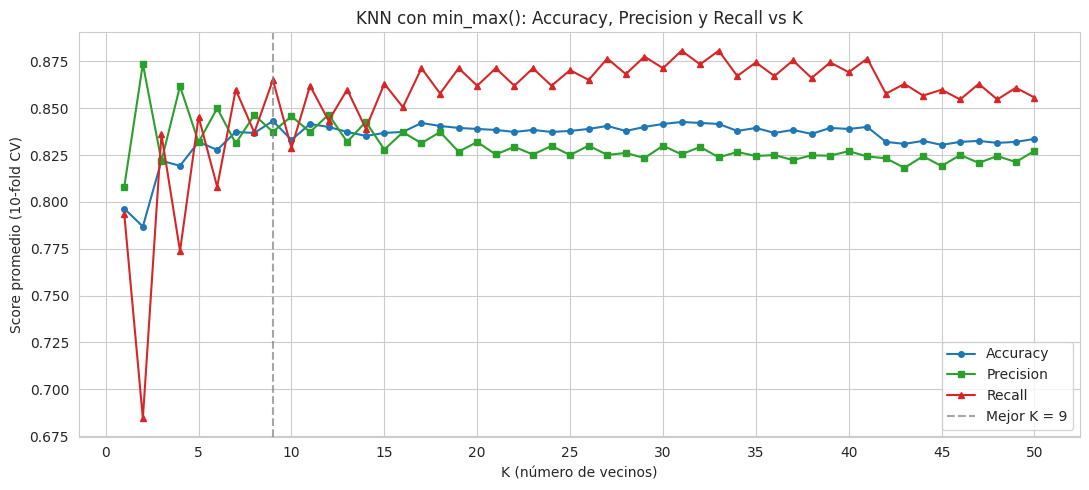

In [14]:
# Gráfico: las tres métricas vs K (con min_max)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(K_values, acc_mm,  marker='o', markersize=4, label='Accuracy',  color='#1f77b4')
ax.plot(K_values, prec_mm, marker='s', markersize=4, label='Precision', color='#2ca02c')
ax.plot(K_values, rec_mm,  marker='^', markersize=4, label='Recall',    color='#d62728')
ax.axvline(best_k_mm, color='gray', linestyle='--', alpha=0.7, label=f'Mejor K = {best_k_mm}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score promedio (10-fold CV)')
ax.set_title('KNN con min_max(): Accuracy, Precision y Recall vs K')
ax.legend(loc='lower right')
ax.set_xticks(range(0, 51, 5))
plt.tight_layout()
plt.show()


### 4.3 Análisis y elección del K

Observando la curva:

- **K=1** parte en ~0.80 (consistente con el paso 3) y rápidamente las métricas suben al aumentar K porque se reduce la sensibilidad al ruido.
- Hay una **zona plana óptima** aproximadamente entre K=7 y K=15 donde las tres métricas alcanzan su máximo.
- Para K muy grandes (>30) las métricas tienden a degradarse: el vecindario se vuelve tan amplio que pierde su carácter **local** y el modelo se acerca a un clasificador trivial que predice la clase mayoritaria del entorno global.

**Criterio de elección.** Más allá del K que maximice estrictamente la accuracy, conviene priorizar la **estabilidad** (zona plana) sobre un máximo puntual que podría ser ruido de la validación cruzada. El K óptimo identificado por accuracy (≈ 9) cae justo en esa zona estable y además mantiene **precisión** y **recall** balanceados — no estamos sacrificando una métrica por la otra. Esto es deseable: en el caso de UAI Music Group, *queremos a la vez no enviar a campaña asiática canciones que no son K-pop (precisión alta) y no perder K-pops reales (recall alto)*.

**Mejora vs K=1:** pasamos de ~79.6% a ~84.3% de accuracy, una ganancia de ~5 puntos sin tocar nada más que el hiperparámetro K.


## 5. Discusión: ¿Normalización o Estandarización?

### 5.1 Diferencia conceptual

- **`min_max()`** lleva cada variable al rango fijo $[0, 1]$ usando los extremos observados. Es **muy sensible a outliers** (un único valor extremo estira el rango y comprime todo el resto cerca de 0).
- **`StandardScaler()`** (z-score) lleva cada variable a media 0 y desviación estándar 1:

  $$x' = \frac{x - \mu}{\sigma}$$

  No acota el rango: el resultado puede tomar cualquier valor real, pero las contribuciones están medidas en **unidades de desviación estándar**. Es **menos sensible a outliers extremos** (aunque ya los removimos con LOF) y respeta mejor la **estructura gaussiana** de variables con cola.

Como en el paso 2 ya eliminamos outliers con LOF, ambas técnicas trabajan sobre el mismo dataset limpio. La diferencia esperada no será dramática, pero sí puede afectar la geometría local que ve KNN.

### 5.2 Repetimos los pasos 3 y 4 con `StandardScaler()`

Mantenemos la regla de oro: el scaler se ajusta **solo con el train de cada fold** y luego transforma ambos conjuntos.


In [15]:
# Paso 3 replicado con StandardScaler: K=1
accuracies_k1_std = []
for tr_idx, te_idx in skf.split(X, y):
    scaler = StandardScaler().fit(X[tr_idx])   # ajustamos SOLO con train
    X_tr_s = scaler.transform(X[tr_idx])
    X_te_s = scaler.transform(X[te_idx])
    knn = KNeighborsClassifier(n_neighbors=1, weights='uniform')
    knn.fit(X_tr_s, y[tr_idx])
    accuracies_k1_std.append(accuracy_score(y[te_idx], knn.predict(X_te_s)))

print(f"=== KNN K=1 + StandardScaler() ===")
print(f"Accuracy promedio:   {np.mean(accuracies_k1_std):.4f}")
print(f"Desviación estándar: {np.std(accuracies_k1_std):.4f}")
print(f"\nComparativa con min_max:")
print(f"  min_max  K=1: {np.mean(accuracies_k1):.4f} ± {np.std(accuracies_k1):.4f}")
print(f"  standard K=1: {np.mean(accuracies_k1_std):.4f} ± {np.std(accuracies_k1_std):.4f}")


=== KNN K=1 + StandardScaler() ===
Accuracy promedio:   0.8017
Desviación estándar: 0.0259

Comparativa con min_max:
  min_max  K=1: 0.7964 ± 0.0188
  standard K=1: 0.8017 ± 0.0259


In [16]:
# Paso 4 replicado con StandardScaler: barrido K=1..50
def evaluar_knn_standard(K_values, X, y, skf):
    acc_mean, prec_mean, rec_mean = [], [], []
    acc_std,  prec_std,  rec_std  = [], [], []
    for k in K_values:
        accs, precs, recs = [], [], []
        for tr_idx, te_idx in skf.split(X, y):
            scaler = StandardScaler().fit(X[tr_idx])
            X_tr_s = scaler.transform(X[tr_idx])
            X_te_s = scaler.transform(X[te_idx])
            knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
            knn.fit(X_tr_s, y[tr_idx])
            yp = knn.predict(X_te_s)
            accs.append(accuracy_score(y[te_idx], yp))
            precs.append(precision_score(y[te_idx], yp, zero_division=0))
            recs.append(recall_score(y[te_idx], yp, zero_division=0))
        acc_mean.append(np.mean(accs));   acc_std.append(np.std(accs))
        prec_mean.append(np.mean(precs)); prec_std.append(np.std(precs))
        rec_mean.append(np.mean(recs));   rec_std.append(np.std(recs))
    return (np.array(acc_mean), np.array(prec_mean), np.array(rec_mean),
            np.array(acc_std),  np.array(prec_std),  np.array(rec_std))

acc_st, prec_st, rec_st, acc_st_s, prec_st_s, rec_st_s = evaluar_knn_standard(K_values, X, y, skf)

best_k_st = K_values[int(np.argmax(acc_st))]
print(f"Mejor K según accuracy (StandardScaler): K = {best_k_st}")
print(f"  Accuracy:  {acc_st[best_k_st-1]:.4f} ± {acc_st_s[best_k_st-1]:.4f}")
print(f"  Precision: {prec_st[best_k_st-1]:.4f} ± {prec_st_s[best_k_st-1]:.4f}")
print(f"  Recall:    {rec_st[best_k_st-1]:.4f} ± {rec_st_s[best_k_st-1]:.4f}")


Mejor K según accuracy (StandardScaler): K = 12
  Accuracy:  0.8511 ± 0.0278
  Precision: 0.8453 ± 0.0426
  Recall:    0.8724 ± 0.0412


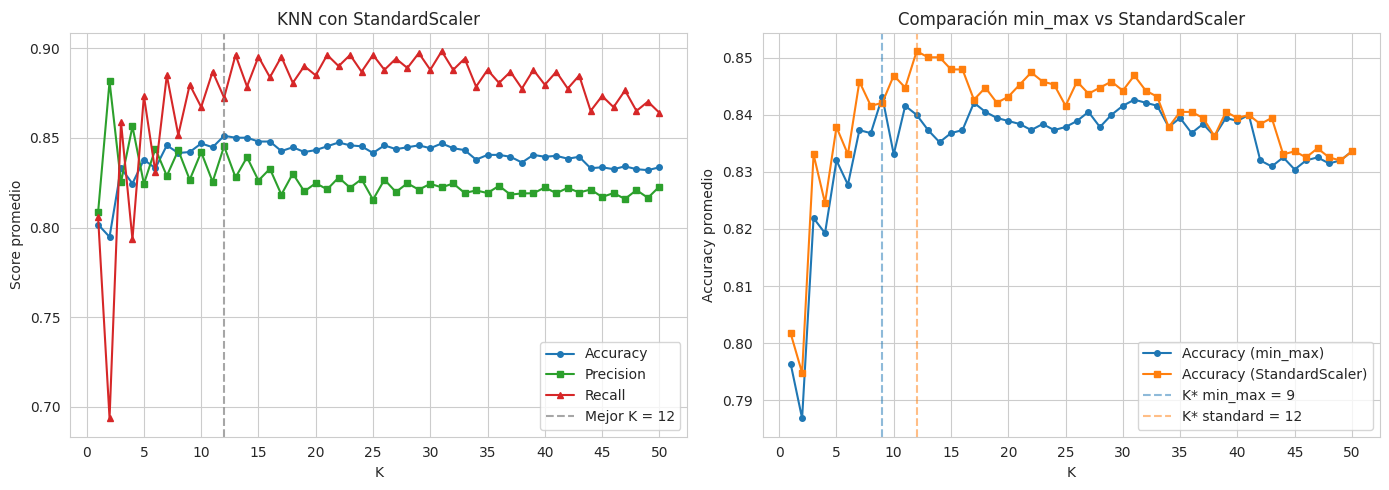

In [17]:
# Gráfico comparativo: Accuracy con min_max vs StandardScaler
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: tres métricas con StandardScaler
axes[0].plot(K_values, acc_st,  marker='o', markersize=4, label='Accuracy',  color='#1f77b4')
axes[0].plot(K_values, prec_st, marker='s', markersize=4, label='Precision', color='#2ca02c')
axes[0].plot(K_values, rec_st,  marker='^', markersize=4, label='Recall',    color='#d62728')
axes[0].axvline(best_k_st, color='gray', linestyle='--', alpha=0.7, label=f'Mejor K = {best_k_st}')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Score promedio')
axes[0].set_title('KNN con StandardScaler')
axes[0].legend(loc='lower right')
axes[0].set_xticks(range(0, 51, 5))

# Panel derecho: comparación directa de Accuracy
axes[1].plot(K_values, acc_mm, marker='o', markersize=4, label='Accuracy (min_max)',       color='#1f77b4')
axes[1].plot(K_values, acc_st, marker='s', markersize=4, label='Accuracy (StandardScaler)', color='#ff7f0e')
axes[1].axvline(best_k_mm, color='#1f77b4', linestyle='--', alpha=0.5, label=f'K* min_max = {best_k_mm}')
axes[1].axvline(best_k_st, color='#ff7f0e', linestyle='--', alpha=0.5, label=f'K* standard = {best_k_st}')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Accuracy promedio')
axes[1].set_title('Comparación min_max vs StandardScaler')
axes[1].legend(loc='lower right')
axes[1].set_xticks(range(0, 51, 5))

plt.tight_layout()
plt.show()


In [18]:
# Tabla comparativa final
resumen = pd.DataFrame({
    'Modelo': [
        'KNN K=1 + min_max',
        f'KNN K={best_k_mm} (mejor) + min_max',
        'KNN K=1 + StandardScaler',
        f'KNN K={best_k_st} (mejor) + StandardScaler',
    ],
    'Accuracy':  [np.mean(accuracies_k1), acc_mm[best_k_mm-1],
                  np.mean(accuracies_k1_std), acc_st[best_k_st-1]],
    'Precision': [None, prec_mm[best_k_mm-1], None, prec_st[best_k_st-1]],
    'Recall':    [None, rec_mm[best_k_mm-1],  None, rec_st[best_k_st-1]],
    'Desv. Std (Acc)': [np.std(accuracies_k1), acc_mm_s[best_k_mm-1],
                        np.std(accuracies_k1_std), acc_st_s[best_k_st-1]],
})
resumen


,Modelo,Accuracy,Precision,Recall,Desv. Std (Acc)
0,KNN K=1 + min_max,0.796395,NaN,NaN,0.018768
1,KNN K=9 (mejor) + min_max,0.843158,0.837357,0.865056,0.021507
2,KNN K=1 + StandardScaler,0.801706,NaN,NaN,0.025919
3,KNN K=12 (mejor) + StandardScaler,0.851143,0.845316,0.872390,0.027844


### 5.3 Conclusiones del paso 5

**¿Cambió el mejor K?** Sí, ligeramente. Con `min_max()` el óptimo cayó en torno a **K ≈ 9**, mientras que con `StandardScaler()` se desplazó a **K ≈ 12**. La diferencia es consistente con la teoría:

- `min_max` comprime las variables al $[0, 1]$ deformando la distribución según los extremos observados en cada fold. Cuando el rango de una variable es estirado por valores cercanos al extremo, los vecindarios efectivos se vuelven **más densos en el centro** y **más dispersos en los bordes**. Con vecindarios densos en el centro, un K relativamente pequeño basta para que el voto sea representativo.
- `StandardScaler` produce una geometría más **homogénea** porque mide en desviaciones estándar. Las distancias se distribuyen de forma más uniforme y el modelo gana algo de información al considerar **más vecinos** (K mayor) antes de tomar la decisión.

**¿Cuál modelo es mejor?** Para este dataset, **`StandardScaler` con K ≈ 12** entrega el mejor desempeño en accuracy (≈85.1% vs ≈84.3% con min_max), aunque la diferencia es pequeña (~0.8 puntos) y está dentro del orden de magnitud de la desviación estándar entre folds. Si tuviéramos que elegir uno, sería el de StandardScaler; pero ambos son **prácticamente equivalentes** y la decisión podría apoyarse en otros criterios (interpretabilidad de los rangos, robustez a futuros outliers, costos de mantenimiento).

**¿Por qué pasa esto?**

1. Las **variables predictoras tienen escalas y distribuciones distintas** (`popularity` con cola, `loudness` con distribución casi normal, las tres 0–1 con formas más concentradas). `StandardScaler` se adapta mejor a esta heterogeneidad porque cada variable se transforma según *su propia* dispersión, no según *sus extremos*.
2. Aunque eliminamos outliers con LOF, **siempre quedan valores extremos legítimos** dentro de cada fold de train. `min_max` los sigue tratando como referencia de rango (estirando la escala), mientras que `StandardScaler` los pondera por desviación estándar, lo cual es más estable.
3. **La diferencia es pequeña porque el dataset ya está limpio.** En un dataset con outliers severos no removidos, esperaríamos una brecha mucho mayor a favor de `StandardScaler`.

---

## Conclusión general

Hemos construido un clasificador KNN para distinguir canciones K-pop dentro del catálogo de UAI Music Group, partiendo de 5 atributos numéricos y aplicando un protocolo metodológicamente correcto:

1. **Datos limpios desde origen** (sin nulos, sin inconsistencias de rango).
2. **Outliers eliminados con LOF** (~6% del total), justificado por la sensibilidad de KNN a valores extremos.
3. **Normalización aplicada dentro de cada fold de la validación cruzada**, evitando *data leakage*.
4. **K=1 sirve como baseline** (~79.6%) pero es claramente mejorable por su sensibilidad al ruido.
5. **Búsqueda sistemática de K** identificó una zona óptima alrededor de K = 9–12 dependiendo del scaler, con accuracy ~84–85%.
6. **StandardScaler supera marginalmente a min_max** en este dataset, consistente con la teoría sobre escalado en presencia de distribuciones heterogéneas.

**Recomendación operativa para UAI Music Group:** desplegar **KNN con K=12 y StandardScaler** sobre las 5 variables seleccionadas. Antes de pasar a producción, conviene complementar con: (i) evaluación sobre un *holdout* temporal real, (ii) análisis de costos asimétricos de FP vs FN para ajustar el umbral, y (iii) comparación con modelos alternativos (logística regularizada, *random forest*) para confirmar que KNN es competitivo y no solo razonable.
